# 03. Modeling

`python -m src.run_pipeline`이 만든 결과(`results/`)를 읽어 후보 비교, 최종 성능, 오류 분석을 정리합니다. 모델 선택과 튜닝은 Batch 1만 사용했고, Batch 2는 선택이 끝난 뒤 최종 평가와 오류 원인 확인(진단)에만 사용했습니다. 이 노트북은 그 결과를 해석할 뿐 모델을 바꾸지 않습니다.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from src.config import *
plt.rcParams.update({"font.family": "AppleGothic", "axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
C = {"batch1": "#1f77b4", "batch2": "#e07b00"}
import json
R = RESULTS_DIR
comp = pd.read_csv(R / "candidate_comparison.csv")
perf = pd.read_csv(R / "model_performance.csv")
err = pd.read_csv(R / "predictions_batch2.csv", index_col=0)
sel = json.load(open(R / "selected_model.json", encoding="utf-8"))
print("선택된 모델:", sel["model"], "| Set", sel["feature_set"], "| 하이퍼파라미터:", sel["best_params"])

선택된 모델: ridge_quad | Set A | 하이퍼파라미터: {'model__alpha': 0.001}


## 1. 후보 비교 (Batch 1 안에서만)

Train CV는 Train 36셀의 프로토콜 단위 5-fold 평균, Valid는 Hold-out 10셀, held-out은 두 예측(CV 36셀 + Valid 10셀)을 합친 46셀의 MAPE입니다. 선택 규칙은 held-out MAPE가 가장 낮은 후보이고, 1 표준오차 이내에 더 단순한 모델이 있으면 그 모델입니다. 단순 예측(학습 수명의 중앙값)은 참고용입니다.

,n_features,cv_mape_mean,cv_mape_std,valid_mape,heldout_mape,heldout_se
후보,,,,,,
baseline_median (Set A),2,19.29,6.57,18.96,19.30,2.17
ols (Set A),2,14.38,6.26,9.69,13.29,2.39
ridge (Set A),2,14.51,5.80,9.83,13.40,2.14
ridge (Set B),8,19.71,12.48,8.93,17.11,4.74
elastic_net (Set A),2,12.92,2.66,11.63,12.68,1.26
elastic_net (Set B),8,12.56,5.24,9.58,11.92,1.76
ridge_quad (Set A),3,11.08,3.05,7.23,10.22,1.44
huber (Set A),2,14.53,6.50,9.84,13.43,2.43
huber (Set B),8,14.41,12.16,9.37,13.22,2.82


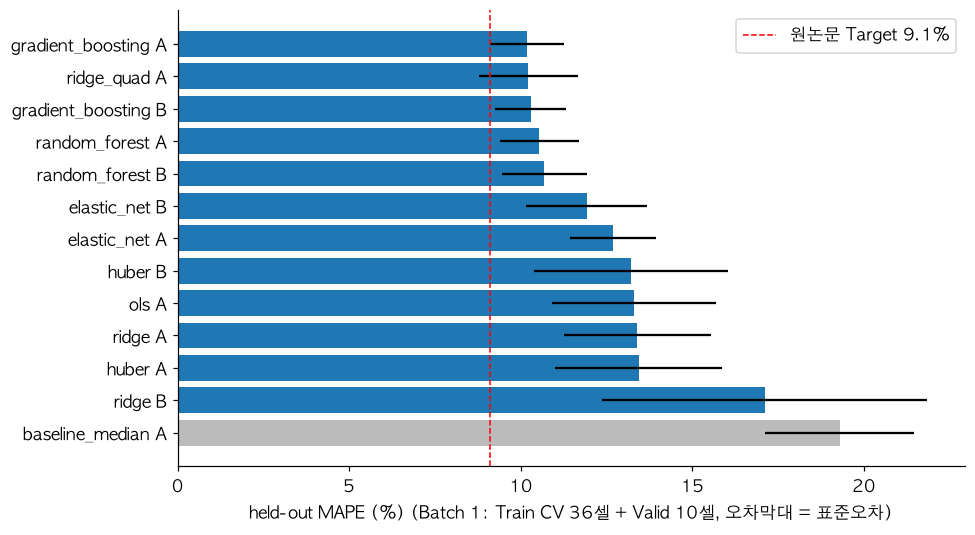

In [2]:
show = comp.assign(후보=comp.model + " (Set " + comp.feature_set + ")")[["후보", "n_features", "cv_mape_mean", "cv_mape_std", "valid_mape", "heldout_mape", "heldout_se"]]
display(show.round(2).set_index("후보"))
fig, ax = plt.subplots(figsize=(9, 5))
d = comp.assign(label=comp.model + " " + comp.feature_set).sort_values("heldout_mape", ascending=False)
ax.barh(d.label, d.heldout_mape, xerr=d.heldout_se, color=["#bbbbbb" if r else "#1f77b4" for r in d.reference_only])
ax.axvline(9.1, color="red", ls="--", lw=1, label="원논문 Target 9.1%")
ax.set_xlabel("held-out MAPE (%) (Batch 1: Train CV 36셀 + Valid 10셀, 오차막대 = 표준오차)"); ax.legend()
plt.tight_layout(); fig.savefig(FIGURES_DIR / "p_candidates.png", bbox_inches="tight"); plt.show()

## 2. 최종 성능 (노션 포맷)

In [3]:
display(perf.round(2).style.hide(axis="index"))

구분,MAPE (%),비고
Train (Batch 1 CV),11.080000,"ridge_quad(Set A), 프로토콜 단위 5-fold, 학습 36셀, fold 표준편차 3.05"
Valid (Batch 1 Hold-out),7.230000,프로토콜 5개 10셀 (Train 36셀로 학습한 모델)
Test (Batch 2),25.180000,"Batch 2 유효 39셀 (Batch 1 46셀로 재학습한 최종 모델, 평가 1회)"
Gap (Train-Valid),-3.860000,(+) : 과적합 의심
Gap (Valid-Test),17.950000,(+) : 배치간 일반화 저하 의심
Gap (Target-Test),16.080000,Target : 원논문 9.1%


## 3. Batch 2 예측 vs 실제

점선은 완벽한 예측입니다. 대부분 점선 위쪽(수명을 실제보다 길게 예측)에 있습니다.

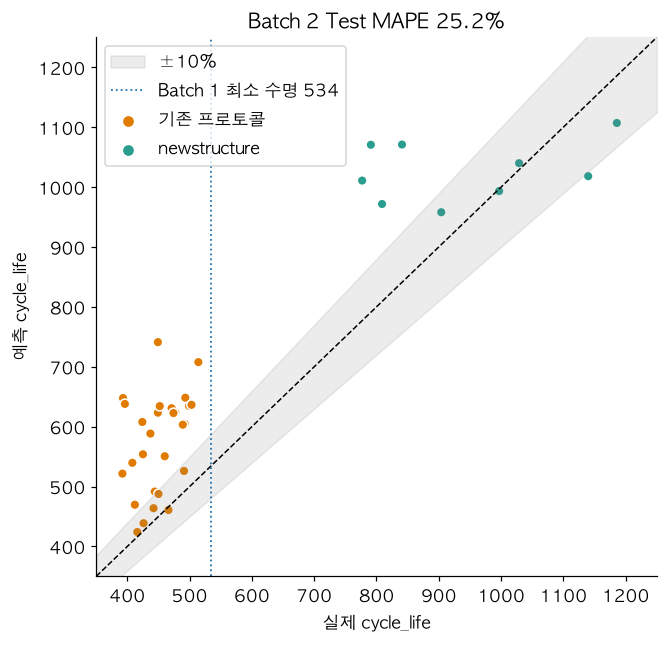

In [4]:
fig, ax = plt.subplots(figsize=(6.2, 6))
sc = ax.scatter(err.cycle_life, err.pred_cycle_life, c=np.where(err.newstructure, "#2a9d8f", "#e07b00"), s=40, edgecolor="white")
lim = [350, 1250]; ax.plot(lim, lim, "k--", lw=1); ax.fill_between(lim, [l * .9 for l in lim], [l * 1.1 for l in lim], color="gray", alpha=.15, label="±10%")
ax.axvline(534, color="#1f77b4", ls=":", lw=1.2, label="Batch 1 최소 수명 534")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_xlabel("실제 cycle_life"); ax.set_ylabel("예측 cycle_life")
ax.scatter([], [], c="#e07b00", label="기존 프로토콜"); ax.scatter([], [], c="#2a9d8f", label="newstructure"); ax.legend(loc="upper left")
ax.set_title(f"Batch 2 Test MAPE {perf.set_index('구분').loc['Test (Batch 2)', 'MAPE (%)']:.1f}%")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "p_pred_vs_actual.png", bbox_inches="tight"); plt.show()

## 4. 오류 분석

### 4-1. 수명 구간별 오차, 편향과 산포

,셀수,MAPE,편향,산포
cycle_life,,,,
<450,15,29.8,29.8,22.3
450~550,15,26.5,26.4,11.1
550~800,2,32.7,32.7,3.7
>800,7,10.3,5.3,13.9


전체: MAPE 25.2% | 편향(부호 있는 평균 오차) +24.2% | 산포(표준편차) 18.5% | 과소예측 셀 4/39


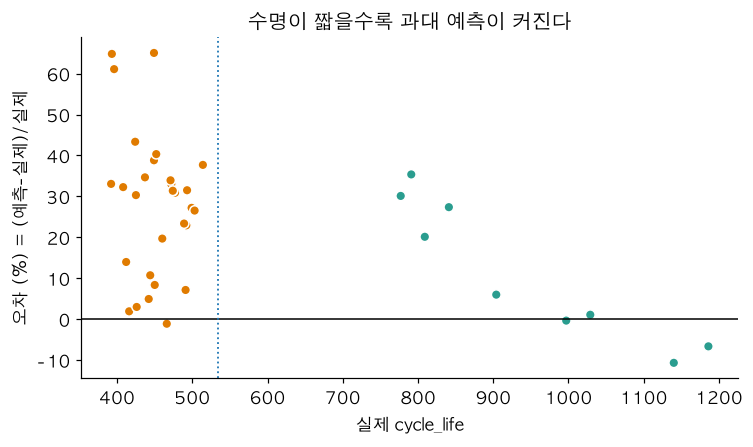

In [5]:
bins = pd.cut(err.cycle_life, [0, 450, 550, 800, 1300], labels=["<450", "450~550", "550~800", ">800"])
byl = err.groupby(bins).agg(셀수=("ape", "size"), MAPE=("ape", "mean"), 편향=("error_pct", "mean"), 산포=("error_pct", "std"))
display(byl.round(1))
print(f"전체: MAPE {err.ape.mean():.1f}% | 편향(부호 있는 평균 오차) {err.error_pct.mean():+.1f}% | 산포(표준편차) {err.error_pct.std():.1f}% | 과소예측 셀 {int((err.error_pct < 0).sum())}/{len(err)}")
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(err.cycle_life, err.error_pct, c=np.where(err.newstructure, "#2a9d8f", "#e07b00"), s=40, edgecolor="white")
ax.axhline(0, color="k", lw=1); ax.axvline(534, color="#1f77b4", ls=":", lw=1.2)
ax.set_xlabel("실제 cycle_life"); ax.set_ylabel("오차 (%) = (예측-실제)/실제"); ax.set_title("수명이 짧을수록 과대 예측이 커진다")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "p_error_by_life.png", bbox_inches="tight"); plt.show()

### 4-2. 가장 크게 틀린 셀 상위 10개

In [6]:
top = err.sort_values("ape", ascending=False).head(10)[["policy", "cycle_life", "pred_cycle_life", "error_pct", "newstructure", "shares_batch1_protocol", "n_features_out_of_range"]]
display(top.round(1))

,policy,cycle_life,pred_cycle_life,error_pct,newstructure,shares_batch1_protocol,n_features_out_of_range
batch2_c018,5.2C(50%)-4.25C,449.0,741.1,65.1,False,False,1
batch2_c006,3.6C(9%)-5C,393.0,647.7,64.8,False,False,0
batch2_c015,3.6C(9%)-5C,396.0,637.9,61.1,False,False,1
batch2_c002,5.2C(50%)-4.25C,424.0,607.8,43.3,False,False,1
batch2_c029,5.2C(58%)-4C,452.0,634.3,40.3,False,False,0
batch2_c011,5.2C(50%)-4.25C,449.0,623.3,38.8,False,False,0
batch2_c024,4.8C(80%)-4.8C,514.0,707.8,37.7,False,True,0
batch2_c009,5.6C(26%)-4.5C-newstructure,791.0,1070.7,35.4,True,False,0
batch2_c028,4.8C(80%)-4.8C,437.0,588.4,34.6,False,True,1
batch2_c017,5.6C(26%)-4.5C,471.0,630.8,33.9,False,False,0


### 4-3. 그룹별 오차

In [7]:
g = pd.read_csv(R / "error_groups_batch2.csv", index_col=[0, 1])
g.index.names = ["구분", "그룹"]
display(g.round(1))

n  mape  bias_pct  spread_pct  mae_cycles
구분               그룹                                                           
newstructure     newstructure 9셀   9.0  15.3      11.4        17.1       130.7
                 기존 프로토콜          30.0  28.1      28.1        17.4       126.4
Batch 1과 같은 프로토콜 겹치지 않음           32.0  23.8      22.6        20.0       123.7
                 겹침                7.0  31.4      31.4         5.0       144.0
ΔQ 양수 구간 있음      ΔQ 양수             4.0  18.4      13.1        21.5       136.5
                 그 외              35.0  26.0      25.5        18.0       126.3
학습 피처 범위 밖       범위 밖 있음          14.0  22.9      22.7        22.2        96.8
                 범위 안             25.0  26.5      25.0        16.5       144.5

### 4-4. 편향 진단: 오차는 절편 이동인가

Batch 1로 학습한 모델의 Batch 2 오차가 대부분 한 방향이면, 같은 기울기에서 절편만 어긋난 것인지 확인합니다. 아래 보정은 Batch 2 정답을 쓰므로 **진단용**이며 모델 성능이나 선택에는 사용하지 않았습니다(실제 운영에서는 새 배치의 정답을 미리 알 수 없습니다).

In [8]:
off = (np.log10(err.pred_cycle_life) - np.log10(err.cycle_life)).mean()
recal = 10 ** (np.log10(err.pred_cycle_life) - off)
ape_recal = ((recal - err.cycle_life).abs() / err.cycle_life * 100).mean()
print(f"log10 평균 오차(절편 어긋남) = {off:+.3f}  -> 예측이 약 {10**off:.2f}배")
print(f"절편만 맞췄을 때 MAPE (진단용): {ape_recal:.1f}%  (보정 전 {err.ape.mean():.1f}%)")

log10 평균 오차(절편 어긋남) = +0.089  -> 예측이 약 1.23배
절편만 맞췄을 때 MAPE (진단용): 12.2%  (보정 전 25.2%)


### 4-5. Batch 1의 EOL 전 종료 9셀: 학습에 포함할 때와 제외할 때 (Batch 1 교차검증, Test 미사용)

DAY 1 계획대로 9셀을 학습에 넣었을 때와 뺐을 때를 Batch 1 교차검증으로 비교했습니다. 평가는 두 경우 모두 같은 셀(나머지 37셀, 9셀 자체)에서 했습니다.

In [9]:
sens = pd.read_csv(R / "sensitivity_pre_eol.csv")
display(sens.round(2).style.hide(axis="index"))

학습 데이터,나머지 37셀 MAPE (%),나머지 37셀 편향 (%),9셀 MAPE (%),9셀 편향 (%)
9셀 포함,11.320000,2.700000,8.070000,-7.600000
9셀 제외,10.000000,0.050000,6.710000,-3.550000


### 4-5-1. ΔQ가 양수가 되는 Batch 2 셀 (DAY 1에서 따로 보기로 한 셀)

In [10]:
dq = pd.read_csv(R / "dq_positive_cells_batch2.csv", index_col=0)
display(dq[["policy", "cycle_life", "pred_cycle_life", "error_pct", "newstructure", "dq_log10_var", "dq_kurtosis"]].round(2))

,policy,cycle_life,pred_cycle_life,error_pct,newstructure,dq_log10_var,dq_kurtosis
batch2_c009,5.6C(26%)-4.5C-newstructure,791.0,1070.75,35.37,True,-4.34,-0.76
batch2_c033,5.2C(58%)-4C-newstructure,1140.0,1018.26,-10.68,True,-4.23,-0.98
batch2_c043,4.8C(80%)-4.8C-newstructure,1029.0,1040.00,1.07,True,-4.27,-0.78
batch2_c046,4.8C(80%)-4.8C,503.0,636.45,26.53,False,-3.51,-1.20


### 4-6. 모델 선택 때문인가, 배치 차이 때문인가 (진단용)

선택되지 않은 후보도 Batch 1 전체로 학습해 Batch 2에 적용해 본 결과입니다. 모델 선택에는 쓰지 않았고, 오차의 원인을 구분하기 위한 진단입니다. 모든 후보의 편향이 (+)이고 오차가 크다면, 모델을 바꾸는 것으로는 해결되지 않는 배치 간 차이가 원인이라는 뜻입니다.

In [11]:
diag = pd.read_csv(R / "diagnostic_all_candidates_batch2.csv")
display(diag.round(1).set_index(["model", "feature_set"]))

Test MAPE (%)  편향 (%)  최소 예측 수명
model             feature_set                                 
baseline_median   A                     72.7    68.2     858.5
ols               A                     36.8    34.8     563.9
ridge             A                     41.6    39.0     603.6
                  B                     55.8    50.4     472.6
elastic_net       A                     45.3    42.2     630.9
                  B                     53.5    49.5     507.5
ridge_quad        A                     25.2    24.2     423.9
huber             A                     35.0    33.3     548.2
                  B                     45.5    41.9     504.0
random_forest     A                     31.2    30.8     597.0
                  B                     37.1    36.2     610.6
gradient_boosting A                     32.0    31.8     554.6
                  B                     36.3    35.6     548.3